## Libraries

In [ ]:
# !pip install -q tensorflow-docs

In [ ]:
import os
import keras
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import itertools
import imageio
from tensorflow_docs.vis import embed
import pickle
import random

## Variables

In [ ]:
MAX_SEQ_LENGTH = 40
NUM_FEATURES = 2048
FRAME_DIM = (160, 120)

BATCH_SIZE = 64
EPOCHS = 30

path_input = "/content/drive/MyDrive/HAR_Lab3_Data/HumanActions/"

## Data preparation


In [ ]:
data_files = []
labels = []

action_names = os.listdir(path_input)

# Taking videos path
for category in action_names:
    folder = os.path.join(path_input, category)
    for file_name in os.listdir(folder):
        name = os.path.join(path_input, category, file_name)

        labels.append(category)
        data_files.append(name)


# train, test split
train_list, test_list, train_label, test_label = train_test_split(data_files, labels, test_size=0.25, random_state=42)

print(f"Total videos for train: {len(train_list)}")
print(f"Total videos for test: {len(test_list)}")

Total videos for train: 449
Total videos for test: 150


### Features extractor - CNN Network


In [ ]:
def build_feature_extractor():
    feature_extractor = keras.applications.InceptionV3(
        weights="imagenet",
        include_top=False,
        pooling="avg",
        input_shape=(FRAME_DIM[1], FRAME_DIM[0], 3),
    )
    preprocess_input = keras.applications.inception_v3.preprocess_input

    inputs = keras.Input((FRAME_DIM[1], FRAME_DIM[0], 3))
    preprocessed = preprocess_input(inputs)

    outputs = feature_extractor(preprocessed)
    return keras.Model(inputs, outputs, name="feature_extractor")

In [ ]:
feature_extractor = build_feature_extractor()

# Label preprocessing with StringLookup.
label_processor = keras.layers.StringLookup(
    num_oov_indices=0, vocabulary=action_names, mask_token=None
)
print(label_processor.get_vocabulary())

['walking', 'boxing', 'handclapping', 'running', 'handwaving', 'jogging']


### Extracting features

In [ ]:
# Funtional functions for preparing data

def load_video(path, max_frames=0, resize=(IMG_SIZE, IMG_SIZE)):
    cap = cv2.VideoCapture(path)
    frames = []
    try:
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            frames.append(frame)

            if len(frames) == max_frames:
                break
    finally:
        cap.release()
    return np.array(frames)

def prepare_all_videos(files, labels):
    num_samples = len(files)
    video_paths = files
    labels = tf.convert_to_tensor(label_processor(np.array(labels)[..., None])).numpy()


    # `frame_masks` and `frame_features` are what we will feed to our sequence model.
    # `frame_masks` will contain a bunch of booleans denoting if a timestep is
    # masked with padding or not.
    frame_masks = np.zeros(shape=(num_samples, MAX_SEQ_LENGTH), dtype="bool")
    frame_features = np.zeros(
        shape=(num_samples, MAX_SEQ_LENGTH, NUM_FEATURES), dtype="float32"
    )

    # For each video.
    for idx, path in enumerate(video_paths):
        # Gather all its frames and add a batch dimension.
        frames = load_video(path, max_frames=MAX_SEQ_LENGTH)
        frames = frames[None, ...]

        # Initialize placeholders to store the masks and features of the current video.
        temp_frame_mask = np.zeros(
            shape=(
                1,
                MAX_SEQ_LENGTH,
            ),
            dtype="bool",
        )
        temp_frame_features = np.zeros(
            shape=(1, MAX_SEQ_LENGTH, NUM_FEATURES), dtype="float32"
        )

        # Extract features from the frames of the current video.
        for i, batch in enumerate(frames):
            # video_length = batch.shape[0]
            # length = min(MAX_SEQ_LENGTH, video_length)
            for j in range(MAX_SEQ_LENGTH):
                temp_frame_features[i, j, :] = feature_extractor.predict(
                    batch[None, j, :], verbose=0,
                )
            temp_frame_mask[i, :MAX_SEQ_LENGTH] = 1  # 1 = not masked, 0 = masked

        frame_features[idx,] = temp_frame_features.squeeze()
        frame_masks[idx,] = temp_frame_mask.squeeze()

    return (frame_features, frame_masks), labels


In [ ]:
train_data, train_labels = prepare_all_videos(train_list, train_label)
print(f"Frame features in train set: {train_data[0].shape}")

Frame features in train set: (449, 40, 2048)


In [ ]:
test_data, test_labels = prepare_all_videos(test_list, test_label)
print(f"Frame masks in test set: {test_data[0].shape}")

Frame masks in test set: (150, 40, 2048)


In [ ]:
test_data[0].shape

(150, 40, 2048)

In [ ]:
with open('/content/drive/MyDrive/datasets.pkl', 'wb') as f:
  pickle.dump((train_data, train_labels, test_data, test_labels), f)

## RNN model

### Training

In [ ]:
# Classes
class_vocab = label_processor.get_vocabulary()

# Inputs: features and masks
frame_features_input = keras.Input((MAX_SEQ_LENGTH, NUM_FEATURES))
mask_input = keras.Input((MAX_SEQ_LENGTH,), dtype="bool")

# Gated Recurrent Unit layers
x = keras.layers.GRU(16, return_sequences=True)(
    frame_features_input, mask=mask_input
)
x = keras.layers.GRU(8)(x)
x = keras.layers.Dropout(0.4)(x)
# Fully connected
x = keras.layers.Dense(8, activation="relu")(x)
# OUtput
output = keras.layers.Dense(len(class_vocab), activation="softmax")(x)

rnn_model = keras.Model([frame_features_input, mask_input], output)

rnn_model.compile(
    loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"]
)

In [ ]:
filepath = "/content/drive/MyDrive/cnn_rnn_weights.h5"
checkpoint = keras.callbacks.ModelCheckpoint(
    filepath, save_weights_only=True, save_best_only=True, verbose=1
)

## Training
history = rnn_model.fit(
    [train_data[0], train_data[1]],
    train_labels,
    validation_split=0.3,
    epochs=EPOCHS,
    callbacks=[checkpoint],
)

## Evaluation
# rnn_model.load_weights(filepath)
_, accuracy = rnn_model.evaluate([test_data[0], test_data[1]], test_labels)
print(f"Test accuracy: {round(accuracy * 100, 2)}%")


Epoch 1/30
10/10 [==============================] - ETA: 0s - loss: 1.7775 - accuracy: 0.2102
Epoch 1: val_loss improved from inf to 1.76117, saving model to /content/drive/MyDrive/cnn_rnn_weights.h5
10/10 [==============================] - 23s 383ms/step - loss: 1.7775 - accuracy: 0.2102 - val_loss: 1.7612 - val_accuracy: 0.2593
Epoch 2/30
10/10 [==============================] - ETA: 0s - loss: 1.6951 - accuracy: 0.2643
Epoch 2: val_loss improved from 1.76117 to 1.69407, saving model to /content/drive/MyDrive/cnn_rnn_weights.h5
10/10 [==============================] - 1s 96ms/step - loss: 1.6951 - accuracy: 0.2643 - val_loss: 1.6941 - val_accuracy: 0.2889
Epoch 3/30
10/10 [==============================] - ETA: 0s - loss: 1.5942 - accuracy: 0.3121
Epoch 3: val_loss improved from 1.69407 to 1.64374, saving model to /content/drive/MyDrive/cnn_rnn_weights.h5
10/10 [==============================] - 1s 91ms/step - loss: 1.5942 - accuracy: 0.3121 - val_loss: 1.6437 - val_accuracy: 0.2963


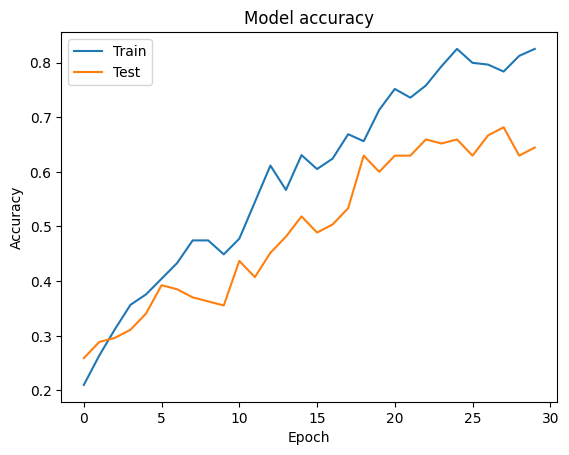

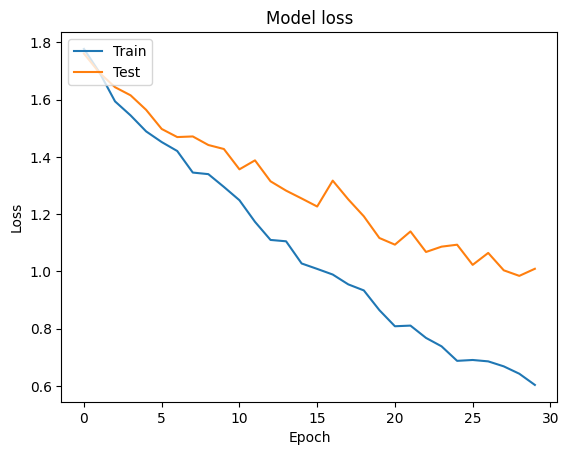

In [ ]:
# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

### Predictions

5/5 [==============================] - 3s 21ms/step


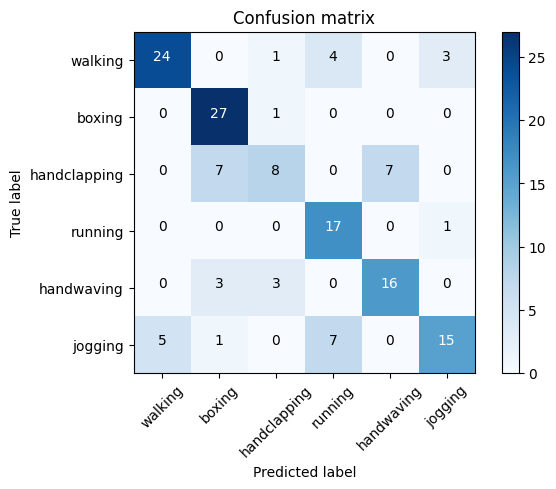

In [ ]:
#  Confusion matrix
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

Y_pred = rnn_model.predict(test_data)
Y_pred_classes = np.argmax(Y_pred,axis = 1)
confusion_mtx = confusion_matrix(test_labels, Y_pred_classes)
plot_confusion_matrix(confusion_mtx, classes = action_names)

### Visualizing predictions

In [ ]:
def prepare_single_video(frames):
    frames = frames[None, ...]
    frame_mask = np.zeros(
        shape=(
            1,
            MAX_SEQ_LENGTH,
        ),
        dtype="bool",
    )
    frame_features = np.zeros(shape=(1, MAX_SEQ_LENGTH, NUM_FEATURES), dtype="float32")

    for i, batch in enumerate(frames):
        video_length = batch.shape[0]
        length = min(MAX_SEQ_LENGTH, video_length)
        for j in range(length):
            frame_features[i, j, :] = feature_extractor.predict(batch[None, j, :])
        frame_mask[i, :length] = 1  # 1 = not masked, 0 = masked

    return frame_features, frame_mask


def predict_action(path, model):
    class_vocab = label_processor.get_vocabulary()

    frames = load_video(path)
    frame_features, frame_mask = prepare_single_video(frames)
    probabilities = model.predict([frame_features, frame_mask])[0]

    for i in np.argsort(probabilities)[::-1]:
        print(f"  {class_vocab[i]}: {probabilities[i] * 100:5.2f}%")
    return frames


def to_gif(images):
    converted_images = images.astype(np.uint8)
    imageio.mimsave("animation.gif", converted_images, fps=10)
    return embed.embed_file("animation.gif")


Test video path: /content/drive/MyDrive/HAR_Lab3_Data/HumanActions/boxing/person03_boxing_d3_uncomp.avi
1/1 [==============================] - 0s 35ms/step
  boxing: 73.51%
  handwaving: 14.75%
  jogging:  6.23%
  running:  3.02%
  handclapping:  1.78%
  walking:  0.71%


<Figure size 640x480 with 0 Axes>

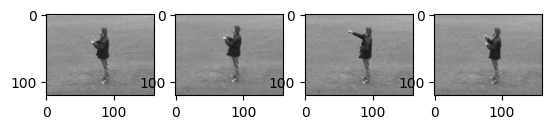

In [ ]:
# Predicting
test_video = test_list[np.random.randint(len(test_data))]
print(f"Test video path: {test_video}")
test_frames = predict_action(test_video, rnn_model)

# Plotting
plt.figure()
f, axarr = plt.subplots(1,4)

frames = load_video(test_video)
frms = random.sample(range(0, len(frames)), 4)
axarr[0].imshow(frames[frms[0]])
axarr[1].imshow(frames[frms[1]])
axarr[2].imshow(frames[frms[2]])
axarr[3].imshow(frames[frms[3]])


Test video path: /content/drive/MyDrive/HAR_Lab3_Data/HumanActions/handwaving/person06_handwaving_d1_uncomp.avi
1/1 [==============================] - 0s 37ms/step
  handwaving: 79.40%
  boxing: 16.78%
  handclapping:  1.60%
  running:  0.85%
  jogging:  0.73%
  walking:  0.64%


<Figure size 640x480 with 0 Axes>

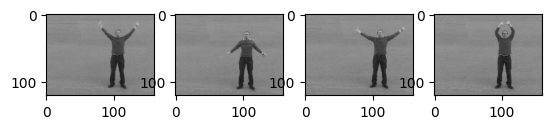

In [ ]:
# Predicting
test_video = test_list[np.random.randint(len(test_data))]
print(f"Test video path: {test_video}")
test_frames = predict_action(test_video, rnn_model)

# Plotting
plt.figure()
f, axarr = plt.subplots(1,4)

frames = load_video(test_video)
frms = random.sample(range(0, len(frames)), 4)
axarr[0].imshow(frames[frms[0]])
axarr[1].imshow(frames[frms[1]])
axarr[2].imshow(frames[frms[2]])
axarr[3].imshow(frames[frms[3]])